In [1]:
# eda04: chain registration transforms, register all exposures to reference (shortest), weighted merge
import math
import numpy as np
import torch
import pickle
import tqdm
from pathlib import Path
from PIL import Image
import enum
from dataclasses import dataclass

class MoonInfoOrigin(enum.Enum):
    DIRECT = 0
    INTERPOLATED = 1

@dataclass
class ImageInfo:
    path: Path
    width: int
    height: int
    avg_brightness: float
    timestamp: float
    exposure_time: float
    moon: tuple[float, float, float] = None
    moon_info_origin: MoonInfoOrigin = None
    moon_pos_std_px: float = None

PKL_DIR = "/home/slavik/tmp"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load eda02 (exposure_groups, opt_results) and eda03 (cross_reg, gamma_by_pair)
with open(f"{PKL_DIR}/eda02.pkl", "rb") as fd:
    exposure_groups = pickle.load(fd)
    reg = pickle.load(fd)
    opt_results = pickle.load(fd)
with open(f"{PKL_DIR}/eda03.pkl", "rb") as fd:
    cross_reg = pickle.load(fd)
    gamma_by_pair = pickle.load(fd)

exposure_times_sorted = sorted(exposure_groups.keys())
# Reference = first (shortest) exposure
t_ref = exposure_times_sorted[0]

def moon_median(group):
    centers_i = [ii.moon[0] for ii in group]
    centers_j = [ii.moon[1] for ii in group]
    radii = [ii.moon[2] for ii in group]
    return (float(np.median(centers_i)), float(np.median(centers_j)), float(np.median(radii)))

moon_ref = moon_median(exposure_groups[t_ref])
print(f"Reference exposure t_ref={t_ref}, moon_ref (i,j,r)={moon_ref}")
print(f"cross_reg pairs: {len(cross_reg)}, gamma_by_pair: {len(gamma_by_pair)}")

Reference exposure t_ref=0.00025, moon_ref (i,j,r)=(1975.8032373889234, 2872.06197001884, 316.0698799244132)
cross_reg pairs: 16, gamma_by_pair: 16


In [2]:
# Recompute per-exposure averaged images (same logic as eda03; not saved there)
def load_grayscale(ii, device):
    with Image.open(ii.path) as img:
        arr = np.array(img).astype(np.float32) / 255.0
    if arr.ndim == 3:
        arr = arr.mean(axis=2)
    return torch.from_numpy(arr).to(device=device, dtype=torch.float32)

def apply_transform_single(img, shift_i, shift_j, angle_deg, device):
    H, W = img.shape
    ci, cj = H / 2.0, W / 2.0
    angle_rad = math.radians(-angle_deg)
    cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    di = ii - ci - shift_i
    dj = jj - cj - shift_j
    i_src = di * cos_a + dj * sin_a + ci
    j_src = -di * sin_a + dj * cos_a + cj
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    grid = torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

def compute_weighted_average(group, abs_xy, abs_angle_t, device, epsilon=1e-6):
    n = len(group)
    sum_img = None
    sum_mask = None
    for j in range(n):
        img_j = load_grayscale(group[j], device)
        mj_i, mj_j, r_j = group[j].moon[0], group[j].moon[1], group[j].moon[2]
        H, W = img_j.shape
        ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
        jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
        dist = torch.sqrt((ii - mj_i) ** 2 + (jj - mj_j) ** 2)
        mask_j = (dist > r_j + 2.0).to(torch.float32)
        x_j = float(abs_xy[j, 0])
        y_j = float(abs_xy[j, 1])
        theta_j_deg = -math.degrees(float(abs_angle_t[j]))
        w_img = apply_transform_single(img_j, x_j, y_j, theta_j_deg, device)
        w_mask = apply_transform_single(mask_j, x_j, y_j, theta_j_deg, device)
        if sum_img is None:
            sum_img = w_img * w_mask
            sum_mask = w_mask.clone()
        else:
            sum_img = sum_img + w_img * w_mask
            sum_mask = sum_mask + w_mask
    avg_img = sum_img / (sum_mask + epsilon)
    return avg_img

avg_images = {}
for exp in tqdm.tqdm(exposure_times_sorted, desc="Averaged images"):
    group = exposure_groups[exp]
    if exp not in opt_results or len(group) < 2:
        continue
    abs_xy = torch.from_numpy(opt_results[exp]["abs_xy"]).to(device)
    abs_angle_t = torch.from_numpy(opt_results[exp]["abs_angle_t"]).to(device)
    avg_images[exp] = compute_weighted_average(group, abs_xy, abs_angle_t, device)

print(f"Built {len(avg_images)} averaged images.")
H_ref, W_ref = next(iter(avg_images.values())).shape
print(f"Reference shape H={H_ref}, W={W_ref}")

Averaged images: 100%|██████████| 17/17 [00:28<00:00,  1.69s/it]

Built 17 averaged images.
Reference shape H=4000, W=6000


In [3]:
# Build ref->k sampling grid by chaining pairwise transforms; scale factor to ref intensity
def ref_to_source_grid(H, W, chain_tuples, device):
    """chain_tuples: list of (shift_i, shift_j, rotation_deg) for (t0,t1), (t1,t2), ..."""
    ci, cj = H / 2.0, W / 2.0
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    i_cur = ii.clone()
    j_cur = jj.clone()
    for (shift_i, shift_j, rotation_deg) in chain_tuples:
        angle_rad = math.radians(-rotation_deg)
        cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
        di = i_cur - ci - shift_i
        dj = j_cur - cj - shift_j
        i_cur = di * cos_a + dj * sin_a + ci
        j_cur = -di * sin_a + dj * cos_a + cj
    return i_cur, j_cur

def grid_to_normalized_grid(i_src, j_src, H, W):
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    return torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)

def warp_to_ref(img, chain_tuples, H_ref, W_ref, device):
    """Warp img (same or larger concept size) to reference grid using chain ref->source."""
    i_src, j_src = ref_to_source_grid(H_ref, W_ref, chain_tuples, device)
    grid = grid_to_normalized_grid(i_src, j_src, img.shape[0], img.shape[1])
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

# Scale factor to bring exposure t_k value to t_ref scale: value_ref = value_k * scale_k
# scale_k = (t_ref/t_1)^(1/g1) * (t_1/t_2)^(1/g2) * ... * (t_{k-1}/t_k)^(1/g_k)
def scale_to_ref(exposure_times_sorted, gamma_by_pair, k):
    if k == 0:
        return 1.0
    scale = 1.0
    for i in range(k):
        t0, t1 = exposure_times_sorted[i], exposure_times_sorted[i + 1]
        if (t0, t1) not in gamma_by_pair:
            return None
        g = gamma_by_pair[(t0, t1)]
        scale *= (t0 / t1) ** (1.0 / g)
    return scale

# Exposures that have both avg_image and a chain from ref (consecutive pairs present)
exposures_with_chain = [t_ref]
chain_tuples_by_exp = {t_ref: []}  # ref -> ref is identity
for k in range(1, len(exposure_times_sorted)):
    t_k = exposure_times_sorted[k]
    if t_k not in avg_images:
        continue
    chain = []
    valid = True
    for i in range(k):
        t0, t1 = exposure_times_sorted[i], exposure_times_sorted[i + 1]
        if (t0, t1) not in cross_reg:
            valid = False
            break
        chain.append(cross_reg[(t0, t1)])
    if not valid:
        continue
    chain_tuples_by_exp[t_k] = chain
    exposures_with_chain.append(t_k)

print(f"Exposures in chain: {len(exposures_with_chain)}")

Exposures in chain: 17


In [4]:
# Weight from original (untransformed) value: exp(-((y-0.5)/0.1)^2), y clipped to [0,1]
WEIGHT_SIGMA = 0.2

def weight_from_value(y):
    y = np.clip(y, 0.0, 1.0).astype(np.float64)
    return np.exp(-((y - 0.5) / WEIGHT_SIGMA) ** 2)

# Accumulate weighted average in float64; track valid per exposure for crop
sum_val = np.zeros((H_ref, W_ref), dtype=np.float64)
sum_weight = np.zeros((H_ref, W_ref), dtype=np.float64)
valid_all = None  # intersection of warped valid masks (float, 1 where all exposures cover)

for t_k in tqdm.tqdm(exposures_with_chain, desc="Warp and merge"):
    img_k = avg_images[t_k]
    chain = chain_tuples_by_exp[t_k]
    k_idx = exposure_times_sorted.index(t_k)
    scale_k = scale_to_ref(exposure_times_sorted, gamma_by_pair, k_idx)
    if scale_k is None:
        continue

    # Original (unscaled) and scaled value, clipped to [0,1]
    orig = img_k.cpu().numpy().astype(np.float64)
    orig_clip = np.clip(orig, 0.0, 1.0)
    value_scaled = np.clip(orig * scale_k, 0.0, 1.0)
    weight_img = weight_from_value(orig_clip)

    # Warp to reference grid
    val_t = torch.from_numpy(value_scaled.astype(np.float32)).to(device)
    w_t = torch.from_numpy(weight_img.astype(np.float32)).to(device)
    valid_t = torch.ones_like(img_k, device=device, dtype=torch.float32)
    warped_val = warp_to_ref(val_t, chain, H_ref, W_ref, device).cpu().numpy().astype(np.float64)
    warped_w = warp_to_ref(w_t, chain, H_ref, W_ref, device).cpu().numpy().astype(np.float64)
    warped_valid = warp_to_ref(valid_t, chain, H_ref, W_ref, device).cpu().numpy()

    # Only count where this exposure actually covers (avoid border pull-down)
    use = warped_valid >= 0.5
    sum_val += np.where(use, warped_val * warped_w, 0.0)
    sum_weight += np.where(use, warped_w, 0.0)

    if valid_all is None:
        valid_all = warped_valid.copy()
    else:
        valid_all = np.minimum(valid_all, warped_valid)

# Pixels with at least some weight (always true if clipped; defensive)
denom = np.maximum(sum_weight, 1e-20)
composite = (sum_val / denom).astype(np.float64)
print(f"Composite shape {composite.shape}, dtype {composite.dtype}")

Warp and merge: 100%|██████████| 17/17 [00:07<00:00,  2.28it/s]

Composite shape (4000, 6000), dtype float64


In [5]:
# Crop to rectangle where all exposures have valid coverage (valid_all >= 0.5)
VALID_THRESH = 0.5
all_valid_mask = valid_all >= VALID_THRESH
rows = np.any(all_valid_mask, axis=1)
cols = np.any(all_valid_mask, axis=0)
r_lo, r_hi = np.where(rows)[0][[0, -1]]
c_lo, c_hi = np.where(cols)[0][[0, -1]]
composite_crop = composite[r_lo : r_hi + 1, c_lo : c_hi + 1].copy()
# Moon center in ref image; crop offset for moon fill
mi, mj, moon_r = moon_ref
mi_crop = mi - r_lo
mj_crop = mj - c_lo
H_crop, W_crop = composite_crop.shape
print(f"Crop bounds rows [{r_lo},{r_hi}], cols [{c_lo},{c_hi}]; shape {composite_crop.shape}")

# Fill moon with black (circle from reference exposure)
ii = np.arange(H_crop, dtype=np.float64).reshape(-1, 1)
jj = np.arange(W_crop, dtype=np.float64).reshape(1, -1)
dist_sq = (ii - mi_crop) ** 2 + (jj - mj_crop) ** 2
moon_mask = dist_sq <= (moon_r ** 2)
composite_crop[moon_mask] = 0.0
print("Moon filled with black.")

Crop bounds rows [7,3999], cols [0,5989]; shape (3993, 5990)
Moon filled with black.


In [6]:
# Save composite (float64) and a preview image
out_dir = Path(PKL_DIR)
np.save(out_dir / "eda04_composite.npy", composite_crop)
# Preview: normalize to [0,1] for display (or use percentile clip)
v_min = np.percentile(composite_crop[~moon_mask] if np.any(~moon_mask) else composite_crop, 1)
v_max = np.percentile(composite_crop[~moon_mask] if np.any(~moon_mask) else composite_crop, 99)
preview = np.clip((composite_crop - v_min) / (v_max - v_min + 1e-9), 0, 1)
Image.fromarray((preview * 255).clip(0, 255).astype(np.uint8)).save(out_dir / "eda04_composite_preview.png")
print(f"Saved {out_dir / 'eda04_composite.npy'} (float64), {out_dir / 'eda04_composite_preview.png'}")

Saved /home/slavik/tmp/eda04_composite.npy (float64), /home/slavik/tmp/eda04_composite_preview.png


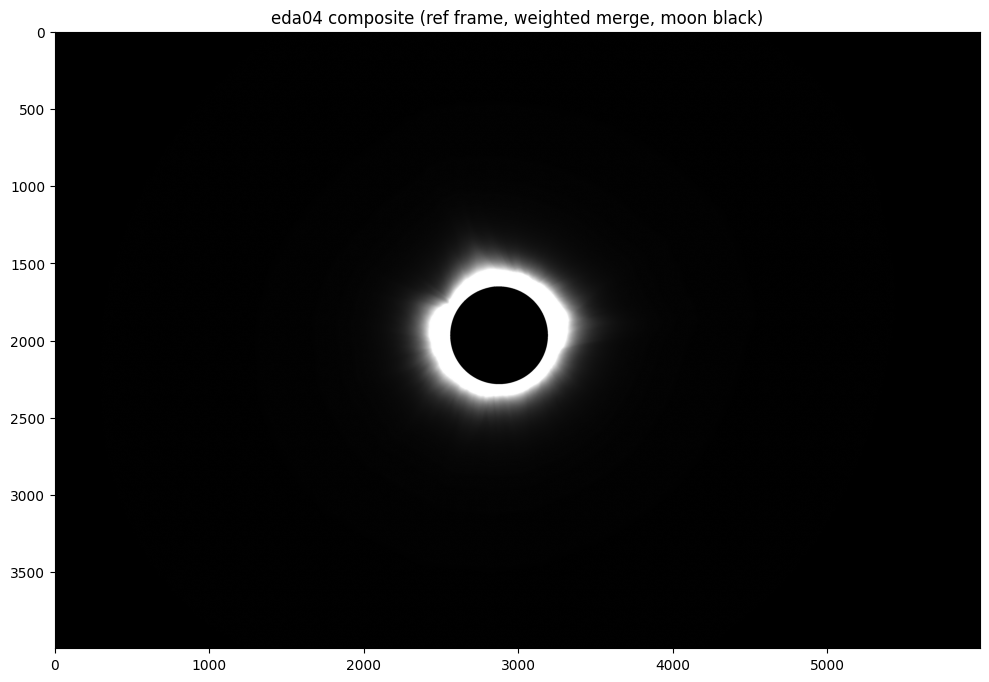

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(composite_crop, cmap="gray", vmin=0, vmax=np.percentile(composite_crop[composite_crop > 0], 99) if np.any(composite_crop > 0) else 1)
ax.set_title("eda04 composite (ref frame, weighted merge, moon black)")
plt.tight_layout()
plt.show()

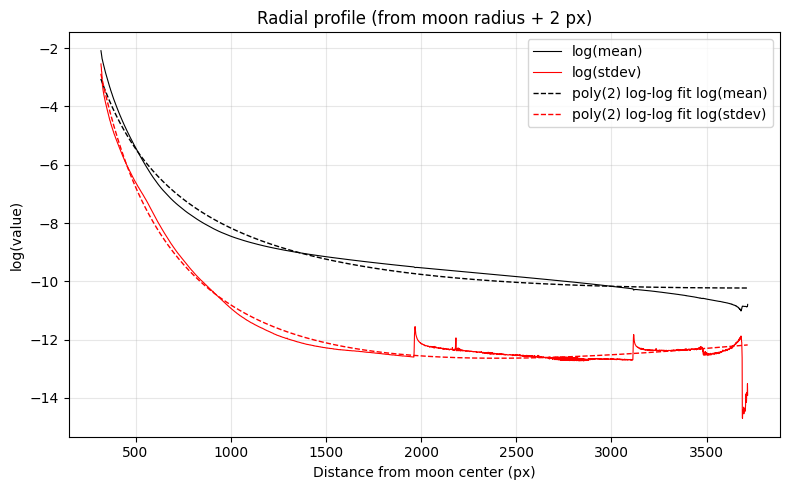

In [8]:
# Radial profile: log(mean pixel value) vs distance from moon center (from moon_r + 2 px)
import matplotlib.pyplot as plt

r_min = moon_r + 2.0
ii = np.arange(H_crop, dtype=np.float64).reshape(-1, 1)
jj = np.arange(W_crop, dtype=np.float64).reshape(1, -1)
dist = np.sqrt((ii - mi_crop) ** 2 + (jj - mj_crop) ** 2)
outside_moon = dist >= r_min

# Bin by distance (1 px bins)
d_flat = dist[outside_moon].ravel()
v_flat = composite_crop[outside_moon].ravel()
d_max = int(np.ceil(d_flat.max()))
bins = np.arange(r_min, d_max + 1.5, 1.0)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_means = np.full(len(bin_centers), np.nan)
bin_stdevs = np.full(len(bin_centers), np.nan)
for i in range(len(bins) - 1):
    mask = (d_flat >= bins[i]) & (d_flat < bins[i + 1])
    if mask.sum() > 0:
        bin_means[i] = np.mean(v_flat[mask])
        bin_stdevs[i] = np.std(v_flat[mask])

valid = np.isfinite(bin_means) & (bin_means > 0)
valid_sd = np.isfinite(bin_stdevs) & (bin_stdevs > 0)
x_plot = bin_centers[valid]
y_plot = np.log(bin_means[valid])
x_sd = bin_centers[valid_sd]
y_sd = np.log(bin_stdevs[valid_sd])

# Fit degree-2 polynomial in log(radius) vs log(value); exclude largest 100 px for fitting
x_domain_max = max(x_plot.max(), x_sd.max())
x_fit_max = x_domain_max - 100.0
mask_fit_m = x_plot <= x_fit_max
mask_fit_s = x_sd <= x_fit_max
coeffs_mean = np.polyfit(np.log(x_plot[mask_fit_m]), y_plot[mask_fit_m], 2)
coeffs_stdev = np.polyfit(np.log(x_sd[mask_fit_s]), y_sd[mask_fit_s], 2)
x_curve = np.linspace(r_min, x_domain_max, 500)
fit_mean = np.polyval(coeffs_mean, np.log(x_curve))
fit_stdev = np.polyval(coeffs_stdev, np.log(x_curve))

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(x_plot, y_plot, "k-", linewidth=0.8, label="log(mean)")
ax.plot(x_sd, y_sd, "r-", linewidth=0.8, label="log(stdev)")
ax.plot(x_curve, fit_mean, "k--", linewidth=1, label="poly(2) log-log fit log(mean)")
ax.plot(x_curve, fit_stdev, "r--", linewidth=1, label="poly(2) log-log fit log(stdev)")
ax.set_xlabel("Distance from moon center (px)")
ax.set_ylabel("log(value)")
ax.set_title("Radial profile (from moon radius + 2 px)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

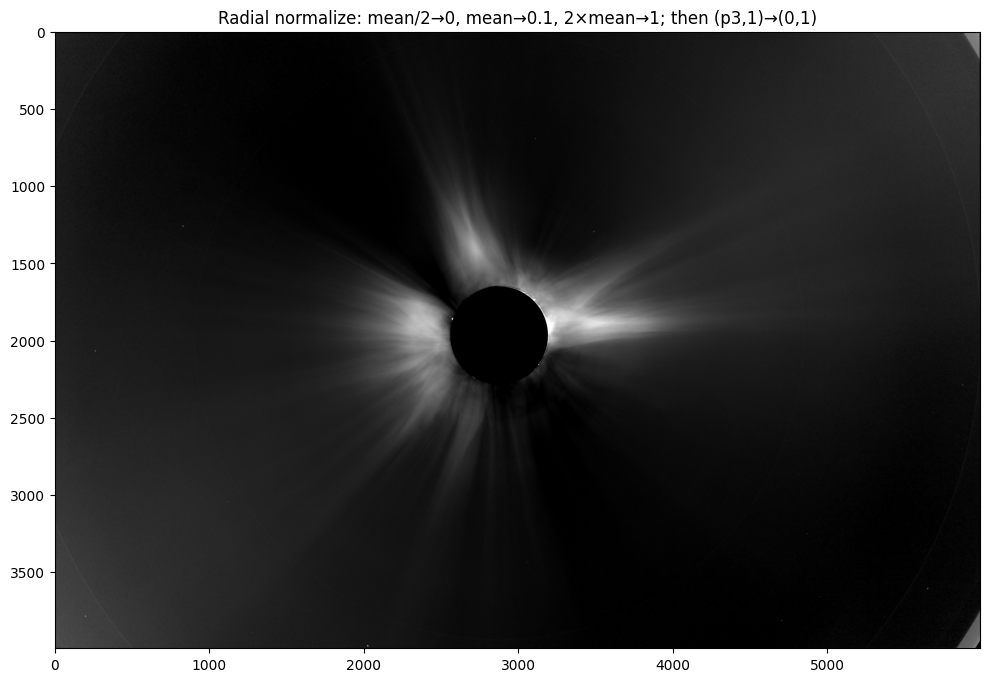

In [9]:
# Mean from binned value; map (mean/2, 2*mean) -> (0,1), grayscale (no stdev)
import matplotlib.pyplot as plt
from PIL import Image

r_min = moon_r + 2.0
ii = np.arange(H_crop, dtype=np.float64).reshape(-1, 1)
jj = np.arange(W_crop, dtype=np.float64).reshape(1, -1)
dist = np.sqrt((ii - mi_crop) ** 2 + (jj - mj_crop) ** 2)
outside_moon = dist >= r_min

# Bin by distance (same as radial profile)
d_flat = dist[outside_moon].ravel()
v_flat = composite_crop[outside_moon].ravel()
d_max = int(np.ceil(d_flat.max()))
bins = np.arange(r_min, d_max + 1.5, 1.0)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_means = np.full(len(bin_centers), np.nan)
for i in range(len(bins) - 1):
    mask = (d_flat >= bins[i]) & (d_flat < bins[i + 1])
    if mask.sum() > 0:
        bin_means[i] = np.mean(v_flat[mask])

# Mean: use raw binned value per pixel
bin_idx = np.searchsorted(bins, dist.ravel(), side="right") - 1
bin_idx = np.clip(bin_idx, 0, len(bin_centers) - 1)
mean_at = bin_means[bin_idx].reshape(H_crop, W_crop)

# Piecewise linear: mean/2 -> 0.0, mean -> 0.1, 2*mean -> 1.0
valid = np.isfinite(mean_at) & (mean_at > 0)
display = np.zeros_like(composite_crop, dtype=np.float64)
v = composite_crop[valid]
m = mean_at[valid]
# mean/2 to mean -> [0, 0.1]; mean to 2*mean -> [0.1, 1.0]
mask1 = (v > m / 2.0) & (v <= m)
mask2 = (v > m) & (v <= 2.0 * m)
mask3 = v > 2.0 * m
display[valid] = np.where(mask1, 0.4 * (v - m / 2.0) / (m / 2.0), 0.0)
display[valid] = np.where(mask2, 0.4 + 0.6 * (v - m) / m, display[valid])
display[valid] = np.where(mask3, 1.0, display[valid])
display[moon_mask] = 0.0

# Last step: 3rd percentile radial profile of display; smooth p3 by median over 45 px radius; remap (p3, 1) -> (0, 1)
v_flat_display = display[outside_moon].ravel()
bin_p3 = np.full(len(bin_centers), np.nan)
for i in range(len(bins) - 1):
    mask = (d_flat >= bins[i]) & (d_flat < bins[i + 1])
    if mask.sum() > 0:
        bin_p3[i] = np.percentile(v_flat_display[mask], 3)
# Smooth p3: median over 100 px radius in distance
p3_radius = 10.0
bin_p3_smooth = np.full(len(bin_centers), np.nan)
for i in range(len(bin_centers)):
    in_window = np.abs(bin_centers - bin_centers[i]) <= p3_radius
    if np.any(np.isfinite(bin_p3[in_window])):
        bin_p3_smooth[i] = np.nanmedian(bin_p3[in_window])
p3_at = np.where(np.isfinite(bin_p3_smooth[bin_idx]), bin_p3_smooth[bin_idx], 0.0).reshape(H_crop, W_crop)
# Linear map (p3_at, 1) -> (0, 1); avoid div by zero when p3 >= 1
span = np.maximum(1.0 - p3_at, 1e-9)
display = (display - p3_at) / span
display = np.clip(display, 0.0, 1.0)
display[moon_mask] = 0.0

Image.fromarray((display * 255).clip(0, 255).astype(np.uint8)).save("/home/slavik/tmp/eda04_radial_normalize.png")

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(display, cmap="gray", vmin=0, vmax=1)
ax.set_title("Radial normalize: mean/2→0, mean→0.1, 2×mean→1; then (p3,1)→(0,1)")
plt.tight_layout()
plt.show()